In [ ]:
!pip install -q kagglehub pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost shap


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    PrecisionRecallDisplay,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE
sns.set(style="whitegrid")


In [ ]:
import kagglehub

path = kagglehub.dataset_download("rohitrox/healthcare-provider-fraud-detection-analysis")
print("Dataset downloaded to:", path)


100%|██████████| 25.4M/25.4M [00:00<00:00, 183MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/rohitrox/healthcare-provider-fraud-detection-analysis/versions/1


In [ ]:
beneficiary = pd.read_csv(f"{path}/Train_Beneficiarydata-1542865627584.csv")
inpatient = pd.read_csv(f"{path}/Train_Inpatientdata-1542865627584.csv")
outpatient = pd.read_csv(f"{path}/Train_Outpatientdata-1542865627584.csv")
labels = pd.read_csv(f"{path}/Train-1542865627584.csv")

beneficiary.shape, inpatient.shape, outpatient.shape, labels.shape


((138556, 25), (40474, 30), (517737, 27), (5410, 2))

In [ ]:
def overview(df, name):
    print("="*80)
    print(f"DATASET: {name}")
    print("="*80)
    print("Shape:", df.shape)
    print("Dtypes:\n", df.dtypes)
    print("Missing:\n", df.isnull().sum())
    print("Head:\n", df.head())
    print("\n\n")

overview(beneficiary, "Beneficiary")
overview(inpatient, "Inpatient")
overview(outpatient, "Outpatient")
overview(labels, "Labels")


DATASET: Beneficiary
Shape: (138556, 25)
Dtypes:
 BeneID                             object
DOB                                object
DOD                                object
Gender                              int64
Race                                int64
RenalDiseaseIndicator              object
State                               int64
County                              int64
NoOfMonths_PartACov                 int64
NoOfMonths_PartBCov                 int64
ChronicCond_Alzheimer               int64
ChronicCond_Heartfailure            int64
ChronicCond_KidneyDisease           int64
ChronicCond_Cancer                  int64
ChronicCond_ObstrPulmonary          int64
ChronicCond_Depression              int64
ChronicCond_Diabetes                int64
ChronicCond_IschemicHeart           int64
ChronicCond_Osteoporasis            int64
ChronicCond_rheumatoidarthritis     int64
ChronicCond_stroke                  int64
IPAnnualReimbursementAmt            int64
IPAnnualDeductibleAmt     

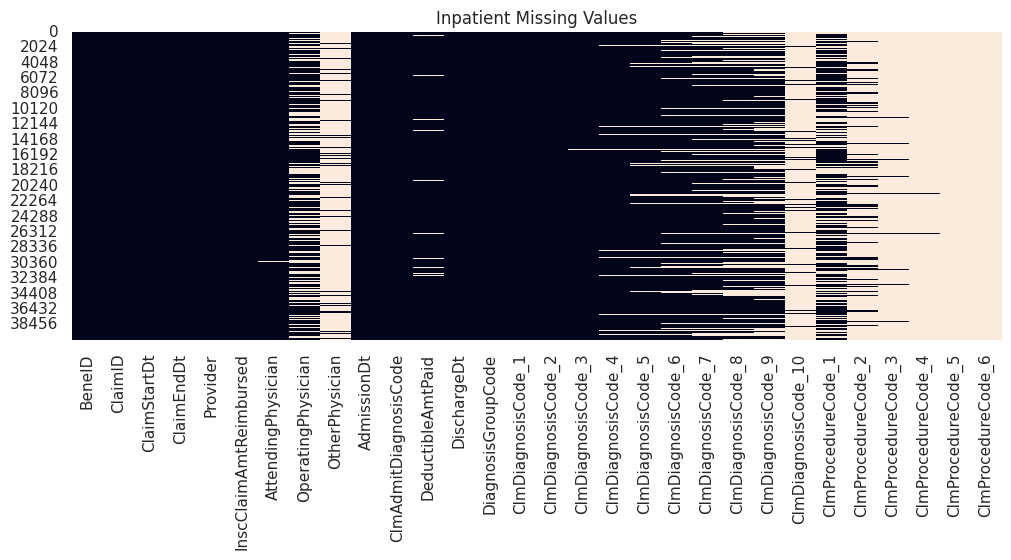

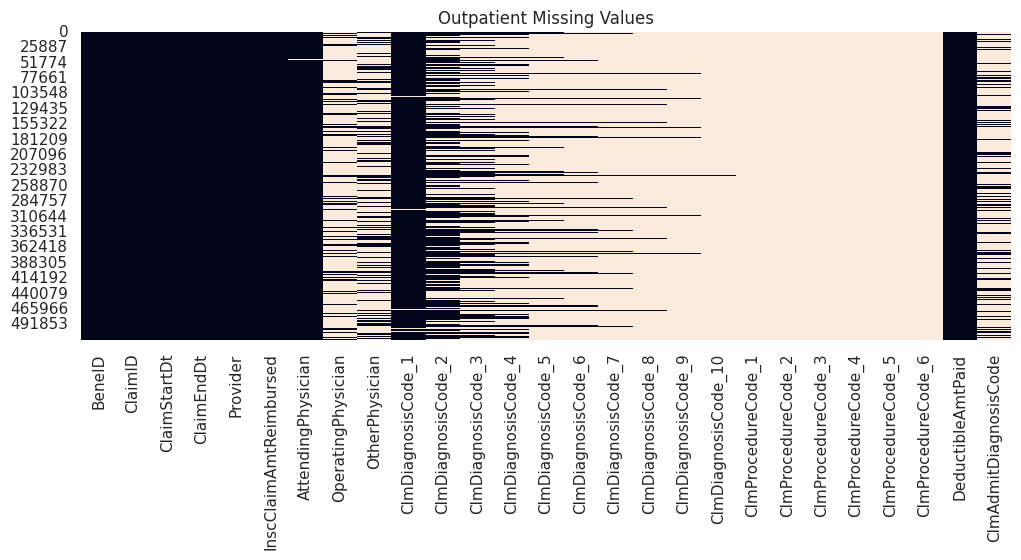

In [ ]:
plt.figure(figsize=(12,4))
sns.heatmap(inpatient.isnull(), cbar=False)
plt.title("Inpatient Missing Values")
plt.show()

plt.figure(figsize=(12,4))
sns.heatmap(outpatient.isnull(), cbar=False)
plt.title("Outpatient Missing Values")
plt.show()


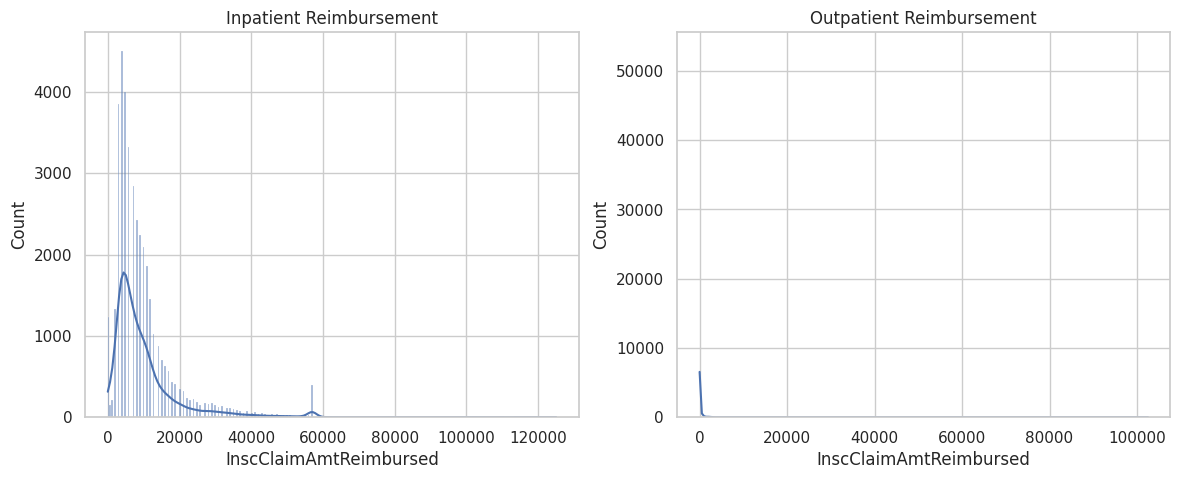

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.histplot(inpatient["InscClaimAmtReimbursed"], kde=True, ax=ax[0])
ax[0].set_title("Inpatient Reimbursement")

sns.histplot(outpatient["InscClaimAmtReimbursed"], kde=True, ax=ax[1])
ax[1].set_title("Outpatient Reimbursement")

plt.show()


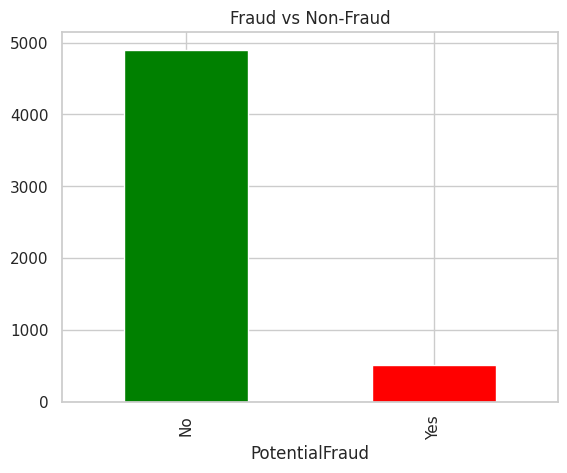

In [ ]:
labels["PotentialFraud"].value_counts().plot(kind="bar", color=["green","red"])
plt.title("Fraud vs Non-Fraud")
plt.show()


In [ ]:
inpatient["ProcedureCount"] = inpatient.filter(like="Procedure").notna().sum(1)
inpatient["DiagnosisCount"] = inpatient.filter(like="Diagnosis").notna().sum(1)

outpatient["ProcedureCount"] = outpatient.filter(like="Procedure").notna().sum(1)
outpatient["DiagnosisCount"] = outpatient.filter(like="Diagnosis").notna().sum(1)


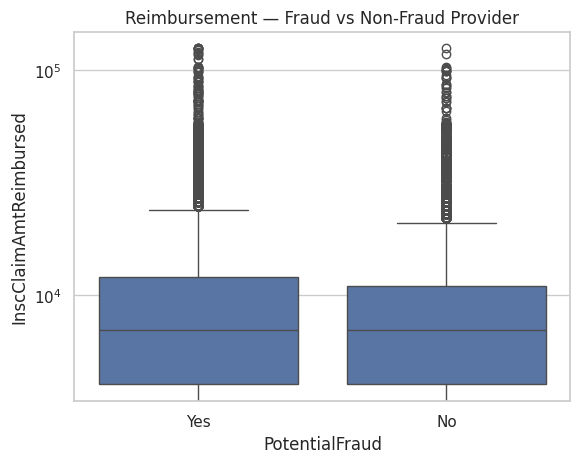

In [ ]:
inpatient_f = inpatient.merge(labels, on="Provider")

sns.boxplot(data=inpatient_f, x="PotentialFraud", y="InscClaimAmtReimbursed")
plt.yscale("log")
plt.title("Reimbursement — Fraud vs Non-Fraud Provider")
plt.show()


In [ ]:
beneficiary.fillna(0, inplace=True)
inpatient.fillna(0, inplace=True)
outpatient.fillna(0, inplace=True)


In [ ]:
from scipy.stats import mstats, zscore
cols = ["InscClaimAmtReimbursed"]

for df in [inpatient, outpatient]:
    for col in cols:
        df[col] = mstats.winsorize(df[col], limits=[0.01,0.01])


In [ ]:
for df in [inpatient, outpatient]:
    df["log_reimb"] = np.log1p(df["InscClaimAmtReimbursed"])


In [ ]:
chronic_cols = [c for c in beneficiary.columns if "Chronic" in c]
beneficiary["ChronicCount"] = beneficiary[chronic_cols].sum(axis=1)


In [ ]:
inpatient_m = inpatient.merge(beneficiary, on="BeneID", how="left")
outpatient_m = outpatient.merge(beneficiary, on="BeneID", how="left")


In [ ]:
inp_agg = inpatient_m.groupby("Provider").agg({
    "ClaimID": "count",
    "InscClaimAmtReimbursed": ["sum","mean"],
    "ProcedureCount": ["sum","mean"],
    "DiagnosisCount": ["sum","mean"],
    "ChronicCount": ["mean"]
})

inp_agg.columns = [
    "Inp_ClaimCount","Inp_ReimbSum","Inp_ReimbMean",
    "Inp_ProcSum","Inp_ProcMean","Inp_DiagSum","Inp_DiagMean",
    "Inp_ChronicMean"
]
